## Algoritmo Isolation Forest Bosque de aislamiento

# **Aprendizaje no supervisado tarea Detección de anomalías**
Introducción

Introducción
Las anomalías, o outliers en inglés, son observaciones con propiedades atípicas (es decir, que se desvían de la tendencia normal). Los valores atípicos indican un problema en los datos o que algo está fuera de lo normal. Un ejemplo de esto podría ser una transacción bancaria sospechosa: John de St. Louis, quien suele contentarse con una o dos visitas a un restaurante a la semana, de repente se compra un smartphone muy costoso en Hanói. Aquí se pueden observar o predecir algunas anomalías. Por ejemplo, podemos estar atentos a las anomalías meteorológicas: si los datos apuntan a un invierno más cálido de lo habitual.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [3]:
data=pd.read_csv('/content/drive/MyDrive/2026/ECBD/U4 Aprendizaje NO supervisado/Deteccion de Anomalias Algoritmo Isolation Forest/supermarket_sales.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [5]:
data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


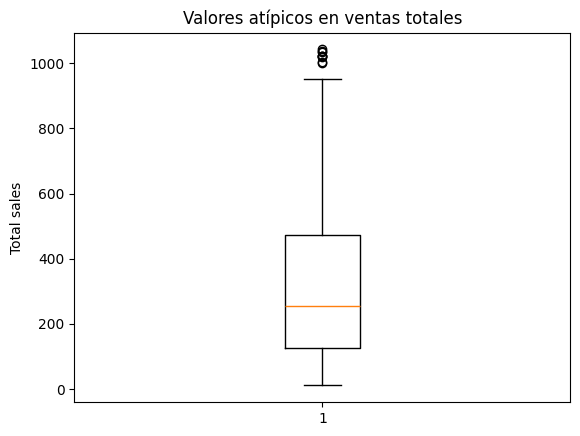

In [7]:
plt.boxplot(data['Total'].values)
plt.ylabel('Total sales')
plt.title("Valores atípicos en ventas totales")
plt.show()


El diagrama muestra información sobre todos los valores atípicos. Se almacena en la lista "fliers" dentro de la instancia de boxplot . Podemos ver cuántos valores atípicos hay llamando a la función get_data() . Los valores necesarios estarán separados por índices.

[np.float64(1003.59), np.float64(1039.29), np.float64(1042.65), np.float64(1002.12), np.float64(1020.705), np.float64(1034.46), np.float64(1023.75), np.float64(1022.385), np.float64(1022.49)]
Valores atípicos:  9


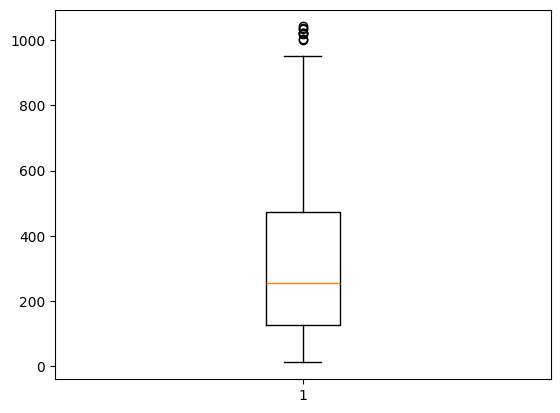

In [8]:
boxplot = plt.boxplot(data['Total'].values)
outliers = list(boxplot["fliers"][0].get_data()[1])
print(outliers)
print("Valores atípicos: ", len(outliers))

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **1. CREACIÓN DEL MODELO UTILIZANDO ELALGORITMO ISOLATION FOREST**

In [ ]:
model_isolation_forest = IsolationForest(n_estimators=100) #cantidad de árboles en el hiperparámetro n_estimators.

In [ ]:
data=data[['Quantity','Unit price', 'Total','Tax 5%']]

# **2. Entrenamiento del modelo**

In [ ]:
model_isolation_forest.fit(data)

IsolationForest()

# **EVALUACIÓN DEL MODELO**
Al llamar a decision_function() veremos exactamente cómo evaluó el modelo las observaciones:

In [ ]:
anomaly_scores = model_isolation_forest.decision_function(data)
anomaly_scores

array([ 1.31352701e-02,  1.87576611e-02,  3.61428104e-02,  2.07832213e-02,
       -2.04735239e-02, -2.47320292e-02,  3.17411301e-02, -4.33109657e-02,
        1.50706127e-02,  3.63800206e-02, -1.56181769e-02,  3.80740887e-02,
        3.90319328e-02, -4.12957293e-02, -5.05877558e-02, -3.88493826e-02,
        1.85312133e-02,  2.99580716e-02,  3.63800206e-02,  2.07577397e-02,
        1.99463558e-03, -6.70469641e-03,  1.16927693e-02,  5.98877832e-02,
       -1.08017182e-02,  3.00806415e-02, -3.96720121e-03, -1.74399770e-02,
       -9.11795716e-03, -9.57234308e-03, -3.79038059e-02, -2.49372086e-02,
       -3.18866919e-02, -4.62466672e-02, -5.45148548e-02,  8.12647865e-03,
        2.96868292e-02, -2.30722740e-02,  2.70652788e-02,  1.30444981e-02,
       -4.87082312e-03,  1.51770515e-02,  2.93404873e-02, -8.98227082e-02,
       -3.58638616e-02, -2.63361647e-02,  3.75706924e-04, -1.34978464e-02,
        1.38520281e-02, -7.33297448e-02, -4.65685495e-02,  4.22033672e-02,
        2.35781729e-02, -

Las estimaciones de anomalías varían entre -0.5 y 0.5. Una estimación más baja indica una mayor probabilidad de que la observación sea un valor atípico.


# **PREDICCIÓN QUE REALIZA EL MODELO**
Para calcular el número de anomalías, llamemos al método predict(), que clasifica las observaciones y distingue las normales de las atípicas. Si la clase de observación es 1, la observación es normal, pero si es -1, es un valor atípico.

In [ ]:
estimator = model_isolation_forest.predict(data)
estimator

array([ 1,  1,  1,  1, -1, -1,  1, -1,  1,  1, -1,  1,  1, -1, -1, -1,  1,
        1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1,  1,  1, -1,  1,  1, -1,  1,  1, -1, -1, -1,  1, -1,  1, -1, -1,
        1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1, -1, -1,  1, -1,  1, -1,
       -1, -1, -1, -1,  1,  1, -1, -1,  1, -1, -1,  1, -1, -1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  1,  1, -1,
       -1,  1,  1, -1,  1,  1, -1, -1, -1, -1,  1, -1, -1,  1,  1,  1, -1,
        1, -1,  1, -1,  1,  1, -1,  1, -1, -1, -1,  1, -1,  1, -1,  1, -1,
        1,  1, -1, -1, -1, -1, -1, -1,  1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1, -1,  1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1, -1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1, -1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,
        1, -1, -1, -1,  1, -1, -1, -1, -1,  1,  1, -1,  1, -1, -1,  1,  1,
        1, -1, -1,  1, -1

Si las estimaciones de anomalías no son necesarias, puedes entrenar el modelo y obtener la clasificación usando fit_predict() :


In [ ]:
estimator = model_isolation_forest.fit_predict(data)
estimator

array([ 1,  1,  1,  1, -1, -1,  1, -1,  1,  1, -1,  1,  1, -1, -1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1, -1, -1, -1, -1,
       -1,  1,  1, -1,  1,  1, -1,  1,  1, -1, -1, -1, -1, -1,  1, -1, -1,
        1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1, -1, -1,  1, -1,  1, -1,
       -1, -1, -1, -1,  1,  1, -1, -1,  1, -1, -1,  1, -1, -1, -1,  1,  1,
       -1,  1,  1, -1,  1,  1, -1,  1, -1, -1, -1, -1, -1,  1, -1, -1, -1,
        1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1, -1,  1,  1, -1, -1,
        1, -1,  1, -1,  1,  1, -1,  1, -1, -1, -1,  1, -1,  1, -1,  1, -1,
        1,  1, -1, -1, -1, -1, -1, -1,  1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1, -1,  1,  1, -1, -1,  1, -1,  1, -1, -1,  1, -1, -1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1, -1,
        1,  1,  1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,
        1,  1, -1, -1,  1, -1, -1, -1, -1,  1,  1, -1,  1, -1, -1,  1,  1,
        1, -1, -1,  1, -1